# Readout Charge-Gate Power with Reference — Analyzer Development
Prototype a new analyzer step by step.  
Load a pre-parsed `xarray.Dataset` from an `.h5` file and explore the raw data.

In [5]:

import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data

## 1. Configuration

In [ ]:
# Path to the pre-parsed xarray Dataset stored as NetCDF4/HDF5
H5_PATH = r"d:\github\LCHQMDriver\data\QPU_project\2026-03-30\#962_LCH_charge_gate_readout_power_with_ref_210926\ds_raw.h5"

# Optional: paths for saving outputs (set to None to skip saving)
METADATA_SAVE_PATH = None   # e.g. r"output/state_disc_results.pkl"
FIGURE_SAVE_PATH   = None   # e.g. r"output/state_disc"

# Optional analysis kwargs
ANALYSIS_KWARGS = {
    # "user_mean": [[0.1, 0.2], [0.3, 0.4]],  # initial guess for GMM centers
    # "user_std": 0.05,                         # initial guess for Gaussian std
    # "outlier_sigma": 3,                       # outlier detection threshold
}

## 2. Load Dataset

In [24]:
dataset = load_xarray_h5(H5_PATH)
dataset

<xarray.Dataset> Size: 4MB
Dimensions:         (shot_idx: 100, charge_gate: 47, amp_prefactor: 9,
                     prepared_state: 2, qubit: 1)
Coordinates:
  * shot_idx        (shot_idx) float64 800B 1.0 2.0 3.0 4.0 ... 98.0 99.0 100.0
  * charge_gate     (charge_gate) float64 376B 0.0 0.01 0.02 ... 0.44 0.45 0.46
  * amp_prefactor   (amp_prefactor) float64 72B 0.0 0.2 0.4 0.6 ... 1.2 1.4 1.6
  * prepared_state  (prepared_state) int32 8B 0 1
  * qubit           (qubit) object 8B 'q1'
Data variables:
    I1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...
    Q1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...
    I1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...
    Q1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...
    I1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...
    Q1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...

In [25]:
sq_data = repetition_data(dataset)[0]
sq_data

<xarray.Dataset> Size: 4MB
Dimensions:         (shot_idx: 100, charge_gate: 47, amp_prefactor: 9,
                     prepared_state: 2)
Coordinates:
  * shot_idx        (shot_idx) float64 800B 1.0 2.0 3.0 4.0 ... 98.0 99.0 100.0
  * charge_gate     (charge_gate) float64 376B 0.0 0.01 0.02 ... 0.44 0.45 0.46
  * amp_prefactor   (amp_prefactor) float64 72B 0.0 0.2 0.4 0.6 ... 1.2 1.4 1.6
  * prepared_state  (prepared_state) int32 8B 0 1
    qubit           <U2 8B 'q1'
Data variables:
    I1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...
    Q1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...
    I1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...
    Q1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...
    I1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...
    Q1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 677kB ...

## 3. Explore Dataset Structure
Inspect dimensions, coordinates, variables, and attributes.

In [26]:

print("=== Dimensions ===")
print(sq_data.dims)
print("\n=== Coordinates ===")
for name, coord in sq_data.coords.items():
    print(f"  {name}: shape={coord.shape}, dtype={coord.dtype}, values={coord.values if coord.size < 20 else f'[{coord.values[0]} ... {coord.values[-1]}] (len={coord.size})'}")
print("\n=== Data Variables ===")
for name, var in sq_data.data_vars.items():
    print(f"  {name}: shape={var.shape}, dims={var.dims}, dtype={var.dtype}")
print("\n=== Attributes ===")
for k, v in sq_data.attrs.items():
    print(f"  {k}: {v}")

=== Dimensions ===
FrozenMappingWarningOnValuesAccess({'shot_idx': 100, 'charge_gate': 47, 'amp_prefactor': 9, 'prepared_state': 2})

=== Coordinates ===
  shot_idx: shape=(100,), dtype=float64, values=[1.0 ... 100.0] (len=100)
  charge_gate: shape=(47,), dtype=float64, values=[0.0 ... 0.46] (len=47)
  amp_prefactor: shape=(9,), dtype=float64, values=[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6]
  prepared_state: shape=(2,), dtype=int32, values=[0 1]
  qubit: shape=(), dtype=<U2, values=q1

=== Data Variables ===
  I1_1: shape=(2, 47, 9, 100), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  Q1_1: shape=(2, 47, 9, 100), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  I1_2: shape=(2, 47, 9, 100), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  Q1_2: shape=(2, 47, 9, 100), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  I1_3: shape=(2, 47, 9, 100), di

## 4. Plot Raw Data
Visualize every data variable across its sweep coordinates.

## 5. Next Steps
Use the cells below to prototype analysis logic (fitting, feature extraction, etc.).  
Once the approach is validated, we will migrate the code into `scqat/protocols/`.

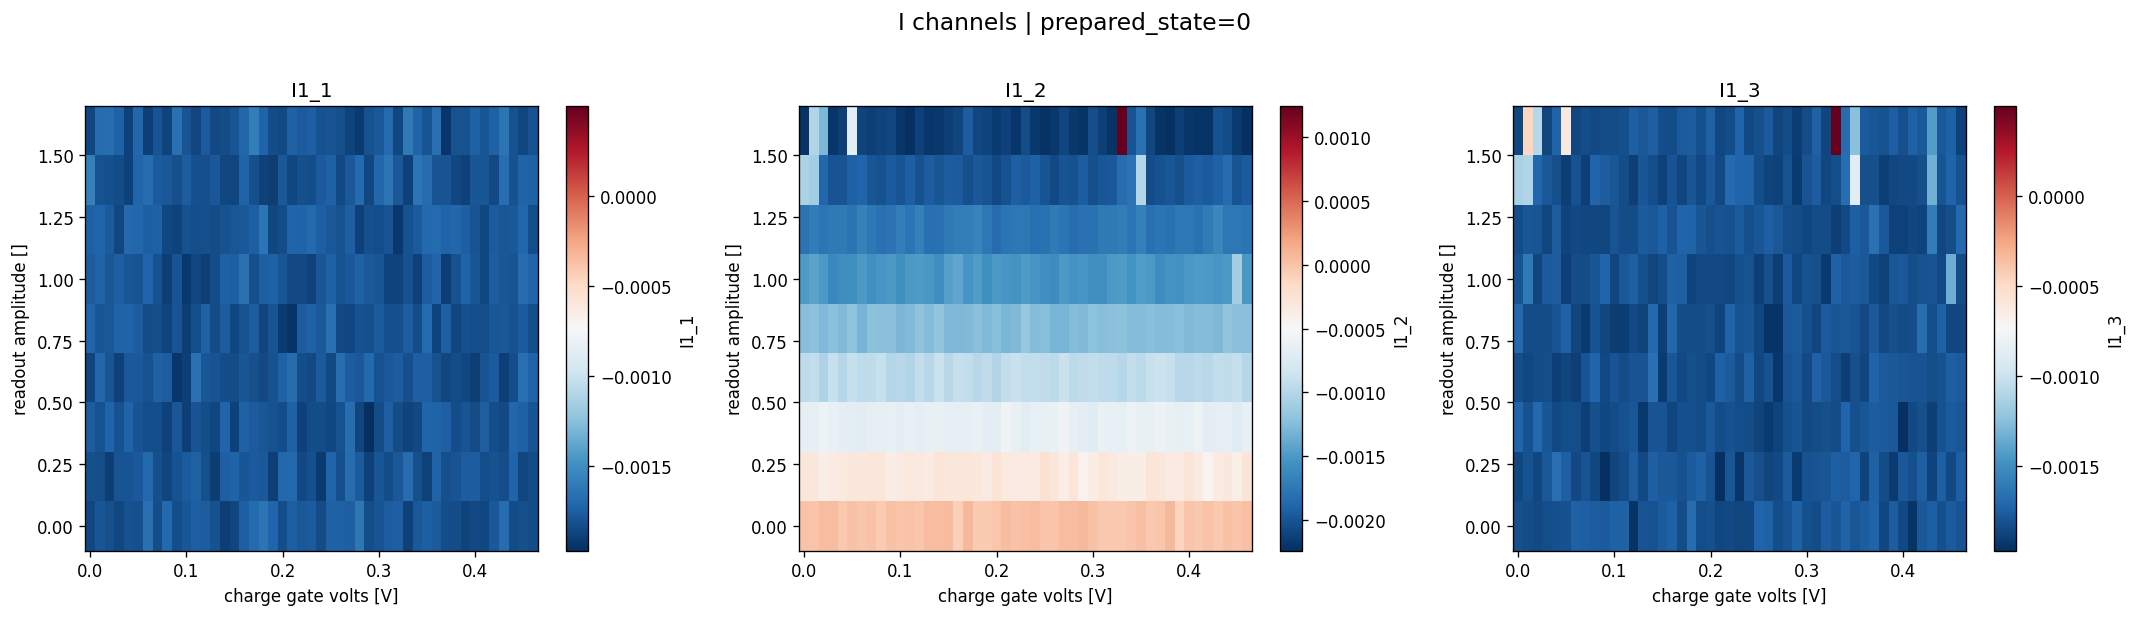

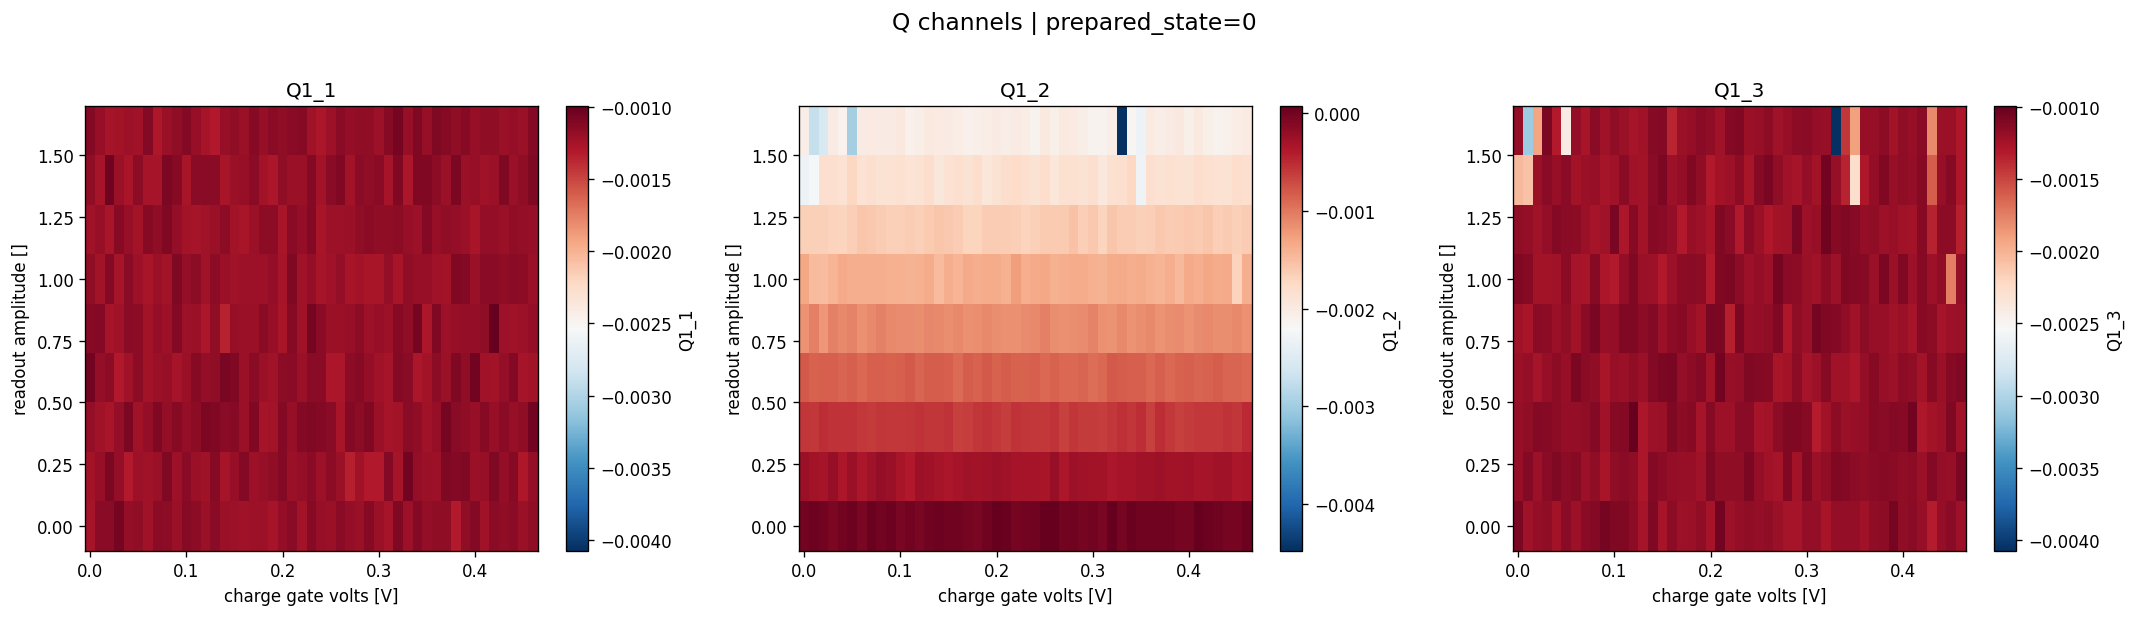

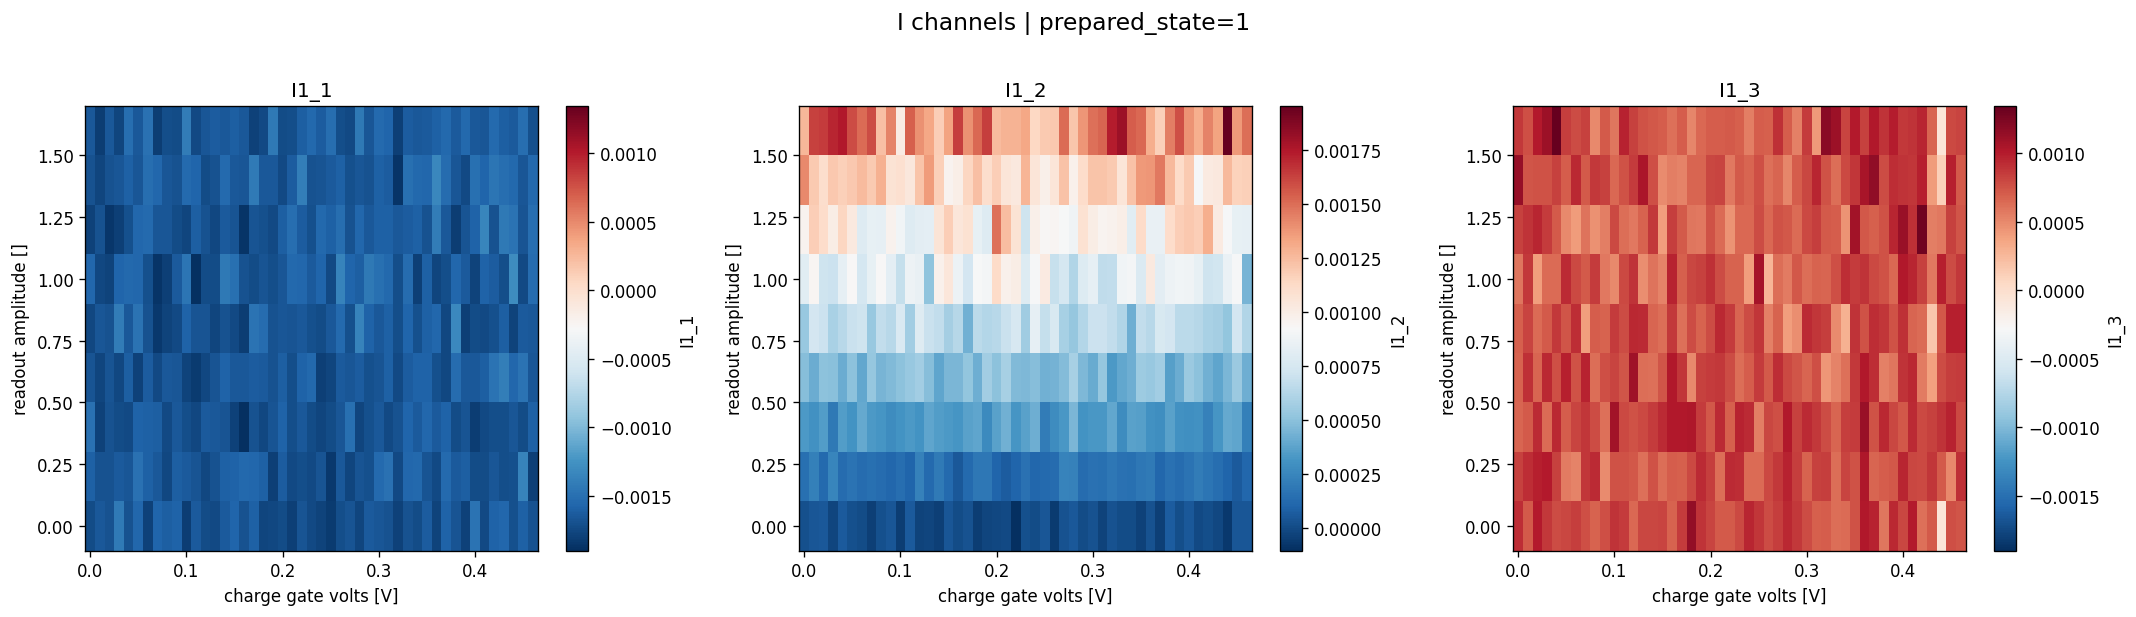

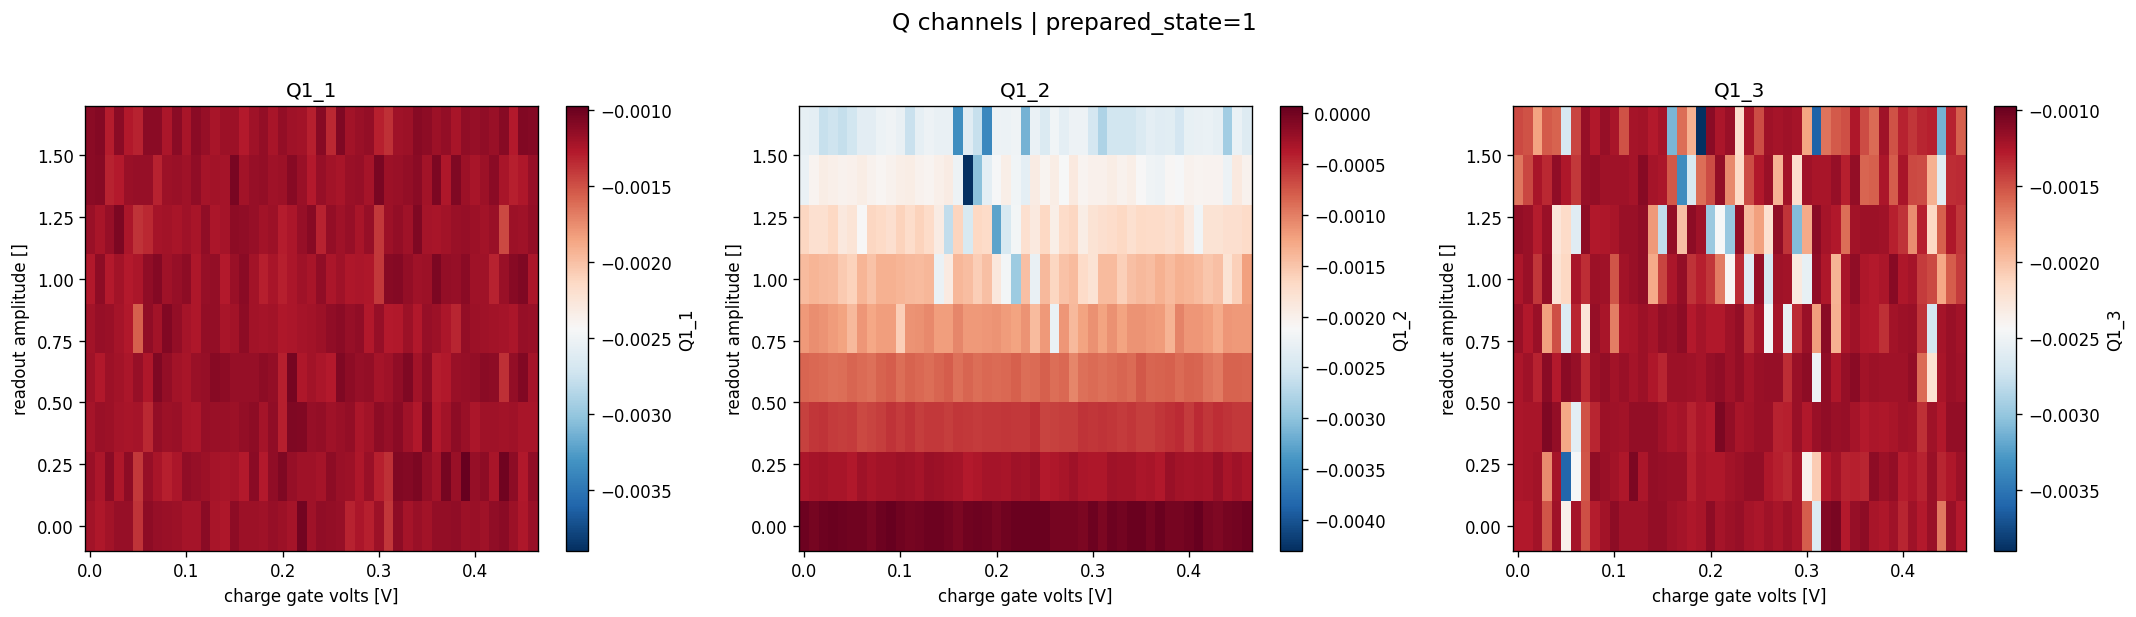

In [28]:
import numpy as np

# Group: I channels and Q channels, subplots for _1, _2, _3
# _1 and _3 share the same colorbar range; _2 has its own
i_vars = ['I1_1', 'I1_2', 'I1_3']
q_vars = ['Q1_1', 'Q1_2', 'Q1_3']
prepared_states = sq_data.coords['prepared_state'].values

for state in prepared_states:
    for group_label, group_vars in [('I', i_vars), ('Q', q_vars)]:
        # Compute means
        means = [sq_data[v].mean(dim='shot_idx').sel(prepared_state=state) for v in group_vars]

        # Shared vmin/vmax for _1 and _3 (index 0 and 2)
        shared_vmin = min(float(means[0].min()), float(means[2].min()))
        shared_vmax = max(float(means[0].max()), float(means[2].max()))

        n = len(group_vars)
        fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), dpi=120, squeeze=False)
        for j, (var_name, mean_da) in enumerate(zip(group_vars, means)):
            if j in (0, 2):  # _1 and _3 share range
                vmin, vmax = shared_vmin, shared_vmax
            else:            # _2 uses its own range
                vmin, vmax = float(mean_da.min()), float(mean_da.max())
            mean_da.plot.pcolormesh(
                ax=axes[0, j], x='charge_gate', y='amp_prefactor',
                cmap='RdBu_r', add_colorbar=True, vmin=vmin, vmax=vmax
            )
            axes[0, j].set_title(var_name)
        fig.suptitle(f"{group_label} channels | prepared_state={state}", fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()